# Multi-Trader Copy Trading Strategy — Grayscale Deployment
# 多交易员跟随组合灰度方案设计

---

## Overview / 方案概述

**Goal:** From ~2000 Hyperliquid trader address samples, build a copy-trading portfolio ready for small-scale real-money trial.

**目标：** 从约2000个Hyperliquid地址样本中，完成**筛选 → 分类 → 配置 → 风控**，形成可灰度试运行的跟单组合。

**This notebook It focuses on** :
- How to filter traders / 如何筛选交易员
- How to organize the portfolio / 如何组织组合
- How to allocate capital / 如何分配资金
- How to control risk / 如何控制风险
- How to iterate in live operation / 如何在试运行中迭代

### Key Assumptions / 关键假设

| Assumption | Value | Rationale |
|---|---|---|
| **Follow mode** / 跟随方式 | Position changes | Lower frequency than raw trades, reduces slippage |
| **Execution delay** / 执行延迟 | ~5 seconds | Signal detection + order placement |
| **Transaction cost** / 交易成本 | 8 bps one-way | 5 bps taker fee + 3 bps slippage |
| **Max leverage** / 最大杠杆 | 3x | Conservative for grayscale phase |
| **Capital** / 初始资金 | $100,000 | Small-scale trial deployment |
| **Cash reserve** / 现金储备 | 10% | Margin buffer + opportunity reserve |
| **Rebalance** / 再平衡周期 | Weekly (7 days) | Balance signal freshness vs. cost |
| **Unified risk control** / 统一风控 | Yes | Portfolio-level overrides individual signals |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from IPython.display import display, HTML

%matplotlib inline
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 150
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except:
    pass

DATA_PATH = "笔试题数据包.csv"
ANN = 365.0  # annualization factor for crypto (24/7 market)
np.random.seed(42)

---
## Stage 1 · Data Loading & Return Computation / 数据加载与收益率计算

**Core Logic / 核心逻辑：**

The raw data provides daily snapshots of each trader's **equity** (account value) and **net_deposit** (cumulative deposits minus withdrawals). To evaluate trader skill, we must isolate **trading PnL** from capital flows.

原始数据提供每个交易员的日快照：**equity**（账户价值）和 **net_deposit**（累计净入金）。为评估交易能力，需将**交易盈亏**与资金流分离。

**Return formula / 收益率公式：**

$$r_t = \frac{(\text{equity}_t - \text{equity}_{t-1}) - (\text{net\_deposit}_t - \text{net\_deposit}_{t-1})}{\text{equity}_{t-1}}$$

For multi-day observation gaps, returns are **geometrically decomposed** to per-day equivalents to avoid overstating single-period returns.

对于多日观测间隔，将收益率**几何分解**为每日等效值，避免高估单期收益。

In [2]:
# ── Load raw data ──
raw = pd.read_csv(DATA_PATH)
raw["date"] = pd.to_datetime(raw["date"])
raw = raw.sort_values(["trader", "date"]).reset_index(drop=True)

print(f"Total records : {len(raw):,}")
print(f"Unique traders: {raw['trader'].nunique()}")
print(f"Date range    : {raw['date'].min().date()} → {raw['date'].max().date()}  ({(raw['date'].max()-raw['date'].min()).days} days)")
print(f"Equity range  : ${raw['equity'].min():,.0f} – ${raw['equity'].max():,.0f}")

# ── Deposit-adjusted daily returns ──
raw["equity_prev"]   = raw.groupby("trader")["equity"].shift(1)
raw["deposit_prev"]  = raw.groupby("trader")["net_deposit"].shift(1)
raw["date_prev"]     = raw.groupby("trader")["date"].shift(1)
raw["deposit_change"] = raw["net_deposit"] - raw["deposit_prev"]
raw["trading_pnl"]   = (raw["equity"] - raw["equity_prev"]) - raw["deposit_change"]
raw["day_gap"]       = (raw["date"] - raw["date_prev"]).dt.days

# Per-observation return
mask = (raw["equity_prev"] > 0) & raw["equity_prev"].notna()
raw["daily_return"] = np.nan
raw.loc[mask, "daily_return"] = raw.loc[mask, "trading_pnl"] / raw.loc[mask, "equity_prev"]

# Geometric decomposition for multi-day gaps
multi = mask & (raw["day_gap"] > 1)
if multi.any():
    gross = (1 + raw.loc[multi, "daily_return"]).clip(lower=0.001)
    raw.loc[multi, "daily_return"] = np.sign(raw.loc[multi, "daily_return"]) * (
        np.abs(gross) ** (1.0 / raw.loc[multi, "day_gap"]) - 1
    )
raw["daily_return"] = raw["daily_return"].clip(-0.99, 10.0)

# Show one sample trader
sample = raw[raw["trader"] == raw["trader"].unique()[5]].head(8)
print("\n── Sample trader snapshot ──")
display(sample[["date","equity","net_deposit","deposit_change","trading_pnl","daily_return"]].round(4))

Total records : 179,355
Unique traders: 2000
Date range    : 2025-07-10 → 2026-01-04  (178 days)
Equity range  : $0 – $108,767,286

── Sample trader snapshot ──


,date,equity,net_deposit,deposit_change,trading_pnl,daily_return
118,2025-07-14,3382.8099,3682.68,NaN,NaN,NaN
119,2025-07-15,3646.3573,3682.68,0.0,263.5475,0.0779
120,2025-07-16,3100.7073,3682.68,0.0,-545.6500,-0.1496
121,2025-07-17,2658.5706,3682.68,0.0,-442.1368,-0.1426
122,2025-07-18,2993.8387,3682.68,0.0,335.2682,0.1261
123,2025-07-19,2865.7155,3682.68,0.0,-128.1232,-0.0428
124,2025-07-20,2722.4956,3682.68,0.0,-143.2199,-0.0500
125,2025-07-21,2446.9584,3682.68,0.0,-275.5372,-0.1012


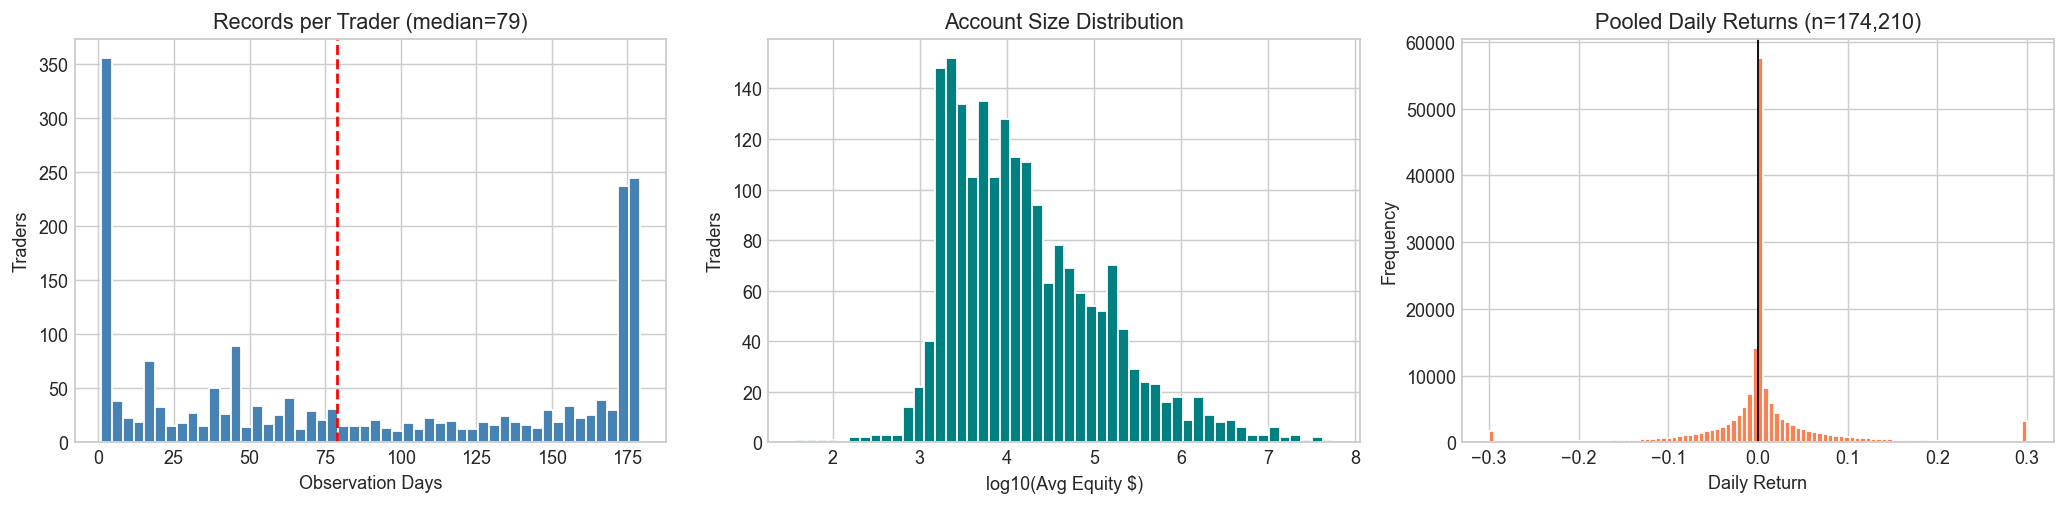

In [3]:
# ── Data overview plots ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Records per trader
rpt = raw.groupby("trader").size()
axes[0].hist(rpt, bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Observation Days"); axes[0].set_ylabel("Traders")
axes[0].set_title(f"Records per Trader (median={rpt.median():.0f})")
axes[0].axvline(rpt.median(), color="red", ls="--", lw=1.5)

# Equity distribution (log)
avg_eq = raw.groupby("trader")["equity"].mean().clip(lower=1)
axes[1].hist(np.log10(avg_eq), bins=50, color="teal", edgecolor="white")
axes[1].set_xlabel("log10(Avg Equity $)"); axes[1].set_ylabel("Traders")
axes[1].set_title("Account Size Distribution")

# Daily return distribution (all traders pooled)
rets_all = raw["daily_return"].dropna()
axes[2].hist(rets_all.clip(-0.3, 0.3), bins=100, color="coral", edgecolor="white")
axes[2].axvline(0, color="black", lw=1)
axes[2].set_xlabel("Daily Return"); axes[2].set_ylabel("Frequency")
axes[2].set_title(f"Pooled Daily Returns (n={len(rets_all):,})")
plt.tight_layout(); plt.show()

---
## Stage 2 · Feature Engineering / 特征工程

Core Logic / 核心逻辑：

为每个交易员计算**27个特征**，涵盖3个维度，看其风险多大、是否稳定、交易风格如何。

| Dimension / 维度 | Features / 特征 | Purpose / 用途 |
|---|---|---|
| **Performance / 表现** | Total return, Sharpe, Sortino, Calmar, win rate, profit factor | Identify skilled traders / 识别有能力的交易员 |
| **Risk / 风险** | Max drawdown, volatility, VaR, CVaR, tail ratio, worst day | Detect uncontrolled risk / 发现不可控风险 |
| **Style / 风格** | Autocorrelation, skewness, kurtosis, activity rate, Sharpe stability | Cluster for diversification / 聚类以实现分散化 |

- **Sharpe/Sortino**: Raw return is meaningless without risk context. A trader with 200% return and 80% drawdown is dangerous to follow.
- **Win rate + Profit factor**: A low-win-rate trader may be profitable overall, but following them requires tolerating many consecutive losses — operationally difficult.
- **Autocorrelation**: Positive = trend-following style; Negative = mean-reversion. Mixing styles provides diversification.
- **Sharpe stability**: A trader whose rolling Sharpe is erratic may have been "lucky" rather than skilled.

In [4]:
# ── Compute all 27 features per trader ──

def compute_features(df):
    """Compute 27 features per trader from observation-level data."""
    records = {}
    for trader, tdf in df.groupby("trader"):
        tdf = tdf.sort_values("date")
        rets   = tdf["daily_return"].dropna().values
        equity = tdf["equity"].values.astype(np.float64)
        dates  = tdf["date"].values
        n_obs, n_ret = len(tdf), len(rets)
        if n_obs < 2: continue

        date_span = max(int((dates[-1] - dates[0]) / np.timedelta64(1,"D")), 1)
        activity  = n_obs / (date_span + 1)

        # ─ Performance ─
        total_ret = (equity[-1] / equity[0] - 1) if equity[0] > 0 else 0.0
        ann_ret   = (1 + total_ret) ** (ANN / date_span) - 1 if total_ret > -1 else -1.0
        if n_ret >= 5:
            mu, sigma = rets.mean(), rets.std(ddof=1)
            sharpe = mu / sigma * np.sqrt(ANN) if sigma > 1e-10 else 0.0
            ds = rets[rets < 0]
            sortino = mu / ds.std(ddof=1) * np.sqrt(ANN) if len(ds) >= 2 and ds.std(ddof=1) > 1e-10 else 10.0
            vol, daily_vol = sigma * np.sqrt(ANN), sigma
        else:
            sharpe = sortino = vol = daily_vol = 0.0

        # Drawdown
        peak = np.maximum.accumulate(equity)
        dd_arr = np.where(peak > 0, (equity - peak) / peak, 0.0)
        max_dd = float(dd_arr.min())
        calmar = (ann_ret / abs(max_dd)) if abs(max_dd) > 1e-10 and date_span >= 5 else 0.0

        win_rate = float((rets > 0).sum() / n_ret) if n_ret > 0 else 0.0
        gains, losses = rets[rets > 0].sum(), abs(rets[rets < 0].sum())
        profit_factor = gains / losses if losses > 1e-10 else 10.0

        # ─ Risk ─
        if n_ret >= 10:
            var5 = float(np.percentile(rets, 5))
            cvar5 = float(rets[rets <= var5].mean()) if (rets <= var5).any() else var5
            p95 = float(np.percentile(rets, 95))
            tail_ratio = abs(p95) / abs(var5) if abs(var5) > 1e-10 else 5.0
        else:
            var5 = cvar5 = 0.0; tail_ratio = 1.0
        worst_day = float(rets.min()) if n_ret > 0 else 0.0
        best_day  = float(rets.max()) if n_ret > 0 else 0.0

        # ─ Style ─
        if n_ret >= 10:
            r1, r2 = rets[:-1], rets[1:]
            d = np.sqrt(((r1 - r1.mean())**2).sum() * ((r2 - r2.mean())**2).sum())
            autocorr = float(((r1 - r1.mean()) * (r2 - r2.mean())).sum() / d) if d > 1e-15 else 0.0
            s = rets.std(ddof=1)
            z = (rets - rets.mean()) / s if s > 1e-15 else np.zeros_like(rets)
            n = float(n_ret)
            skew = float((n / ((n-1)*(n-2))) * (z**3).sum()) if n > 2 else 0.0
            kurt = float((n*(n+1)/((n-1)*(n-2)*(n-3)))*(z**4).sum() - 3*(n-1)**2/((n-2)*(n-3))) if n > 3 else 0.0
        else:
            autocorr = skew = kurt = 0.0

        # Rolling Sharpe stability (std of rolling Sharpe → lower = more consistent)
        if n_ret >= 30:
            rs = pd.Series(rets)
            rm, rstd = rs.rolling(20, min_periods=10).mean(), rs.rolling(20, min_periods=10).std()
            r_sharpe = (rm / rstd.replace(0, np.nan)).dropna()
            sharpe_stab = float(r_sharpe.std()) if len(r_sharpe) > 2 else 10.0
        else:
            sharpe_stab = 10.0

        gaps = np.diff(dates).astype("timedelta64[D]").astype(np.int64) if len(dates) >= 2 else np.array([999])

        records[trader] = dict(
            n_observations=n_obs, n_valid_returns=n_ret, date_span_days=date_span,
            activity_rate=activity, avg_equity=float(equity.mean()), final_pnl=float(tdf["pnl"].iloc[-1]),
            max_gap_days=int(gaps.max()), median_gap_days=float(np.median(gaps)),
            total_return=total_ret, ann_return=ann_ret, sharpe=sharpe, sortino=sortino,
            calmar=calmar, win_rate=win_rate, profit_factor=float(profit_factor),
            max_drawdown=max_dd, volatility=vol, daily_vol=daily_vol,
            var_5pct=var5, cvar_5pct=cvar5, tail_ratio=float(tail_ratio),
            worst_day=worst_day, best_day=best_day,
            return_autocorr=autocorr, skewness=skew, kurtosis=kurt, sharpe_stability=sharpe_stab
        )
    return pd.DataFrame.from_dict(records, orient="index")

features = compute_features(raw)
features.index.name = "trader"
print(f"Computed {len(features.columns)} features for {len(features)} traders")
display(features[["sharpe","sortino","max_drawdown","win_rate","daily_vol","return_autocorr","sharpe_stability"]].describe().round(3))

Computed 27 features for 1948 traders


,sharpe,sortino,max_drawdown,win_rate,daily_vol,return_autocorr,sharpe_stability
count,1948.000,1.948000e+03,1948.000,1948.000,1948.000,1948.000,1948.000
mean,1.721,7.639312e+04,-0.276,0.322,0.147,-0.014,3.429
std,2.286,3.337460e+06,0.307,0.269,0.375,0.144,4.621
min,-18.699,-2.062200e+01,-0.900,0.000,0.000,-1.000,0.000
25%,0.000,2.870000e-01,-0.537,0.043,0.000,-0.053,0.165
50%,1.487,3.150000e+00,-0.144,0.358,0.046,0.000,0.214
75%,2.725,1.000000e+01,0.000,0.517,0.124,0.002,10.000
max,17.605,1.472983e+08,0.000,1.000,4.082,1.000,10.000


---
## Stage 3 · Trader Screening / 交易员筛选

**Core Logic / 核心逻辑：**

We apply **9 independent filters**, each targeting a **specific failure mode** that would make a trader unsuitable for copy trading. The philosophy is **conservative**: false negatives (missing a good trader) are acceptable; false positives (following a bad one) are costly.

我们使用**9项独立筛选**，每项针对一种**特定失败模式**。筛选规则偏好于，宁愿犯typeII，不愿意犯TypeI error：漏掉好交易员可以接受，跟随差交易员代价高昂。

| # | Filter | Threshold | Failure Mode Targeted |
|---|--------|-----------|----------------------|
| 1 | Observation period | ≥ 60 days | **Insufficient history** — can't assess reliability / 样本期不足 |
| 2 | Active trading days | ≥ 30 days | **Dormant account** — no meaningful signal / 休眠账户 |
| 3 | Data continuity | Max gap ≤ 14 days | **Data quality** — large gaps corrupt return estimates / 数据质量 |
| 4 | Account size | Avg equity ≥ $1,000 | **Executability** — micro-accounts have unreliable profiles / 可执行性差 |
| 5 | Sharpe ratio | ≥ 0.5 | **Weak risk-adjusted return** — not worth the complexity of following / 风险调整收益不足 |
| 6 | Max drawdown | ≤ 50% | **Uncontrolled risk** — likely uses extreme leverage / 风险暴露不清晰 |
| 7 | Worst single day | ≥ -40% | **Tail risk / liquidation** — single-event blow-up / 尾部风险 |
| 8 | Win rate | ≥ 35% | **Operational difficulty** — too many consecutive losses make following impractical / 行为不稳定 |
| 9 | Profit factor | ≥ 1.0 | **Net unprofitable** — gains don't exceed losses / 盈亏比不合格 |

In [5]:
# ── Multi-criteria screening ──
SCREEN = dict(min_obs=60, min_active=30, max_gap=14, min_equity=1000,
              min_sharpe=0.5, max_dd=0.50, max_worst=-0.40, min_wr=0.35, min_pf=1.0)

masks = {
    "obs_period":  features["date_span_days"]   >= SCREEN["min_obs"],
    "active_days": features["n_valid_returns"]   >= SCREEN["min_active"],
    "data_gap":    features["max_gap_days"]      <= SCREEN["max_gap"],
    "acct_size":   features["avg_equity"]        >= SCREEN["min_equity"],
    "sharpe":      features["sharpe"]            >= SCREEN["min_sharpe"],
    "max_dd":      features["max_drawdown"]      >= -SCREEN["max_dd"],
    "worst_day":   features["worst_day"]         >= SCREEN["max_worst"],
    "win_rate":    features["win_rate"]           >= SCREEN["min_wr"],
    "profit_fac":  features["profit_factor"]     >= SCREEN["min_pf"],
}
all_pass = pd.DataFrame(masks).all(axis=1)
qualified = features[all_pass].copy()
rejected  = features[~all_pass]

# Composite score for ranking (rank-normalized weighted sum)
def rank_norm(s): return s.rank(pct=True)
qualified["composite_score"] = (
    rank_norm(qualified["sharpe"])        * 0.25 +
    rank_norm(qualified["sortino"])       * 0.15 +
    rank_norm(qualified["calmar"])        * 0.10 +
    rank_norm(qualified["profit_factor"]) * 0.15 +
    rank_norm(-qualified["sharpe_stability"]) * 0.15 +  # lower = better
    rank_norm(qualified["win_rate"])      * 0.10 +
    rank_norm(qualified["tail_ratio"])    * 0.10
)

print(f"Universe : {len(features)} traders")
print(f"Qualified: {len(qualified)} ({len(qualified)/len(features)*100:.1f}%)")
print(f"Rejected : {len(rejected)} ({len(rejected)/len(features)*100:.1f}%)")
print(f"\n── Rejection counts by filter ──")
for name, m in masks.items():
    print(f"  {name:12s}: {(~m).sum():4d} traders failed")
print(f"\n── Qualified trader summary ──")
display(qualified[["sharpe","sortino","max_drawdown","win_rate","profit_factor","composite_score"]].describe().round(3))

Universe : 1948 traders
Qualified: 214 (11.0%)
Rejected : 1734 (89.0%)

── Rejection counts by filter ──
  obs_period  :  381 traders failed
  active_days :  561 traders failed
  data_gap    :  768 traders failed
  acct_size   :   43 traders failed
  sharpe      :  684 traders failed
  max_dd      :  525 traders failed
  worst_day   :  389 traders failed
  win_rate    :  962 traders failed
  profit_fac  :  134 traders failed

── Qualified trader summary ──


,sharpe,sortino,max_drawdown,win_rate,profit_factor,composite_score
count,214.000,214.000,214.000,214.000,214.000,214.000
mean,2.487,5.756,-0.265,0.518,2.362,0.502
std,1.426,6.587,0.132,0.079,4.654,0.203
min,0.512,0.450,-0.498,0.353,1.080,0.120
25%,1.590,2.274,-0.371,0.476,1.317,0.327
50%,2.140,3.845,-0.266,0.520,1.541,0.507
75%,3.095,6.575,-0.163,0.550,1.984,0.684
max,8.460,51.277,-0.005,0.805,65.384,0.934


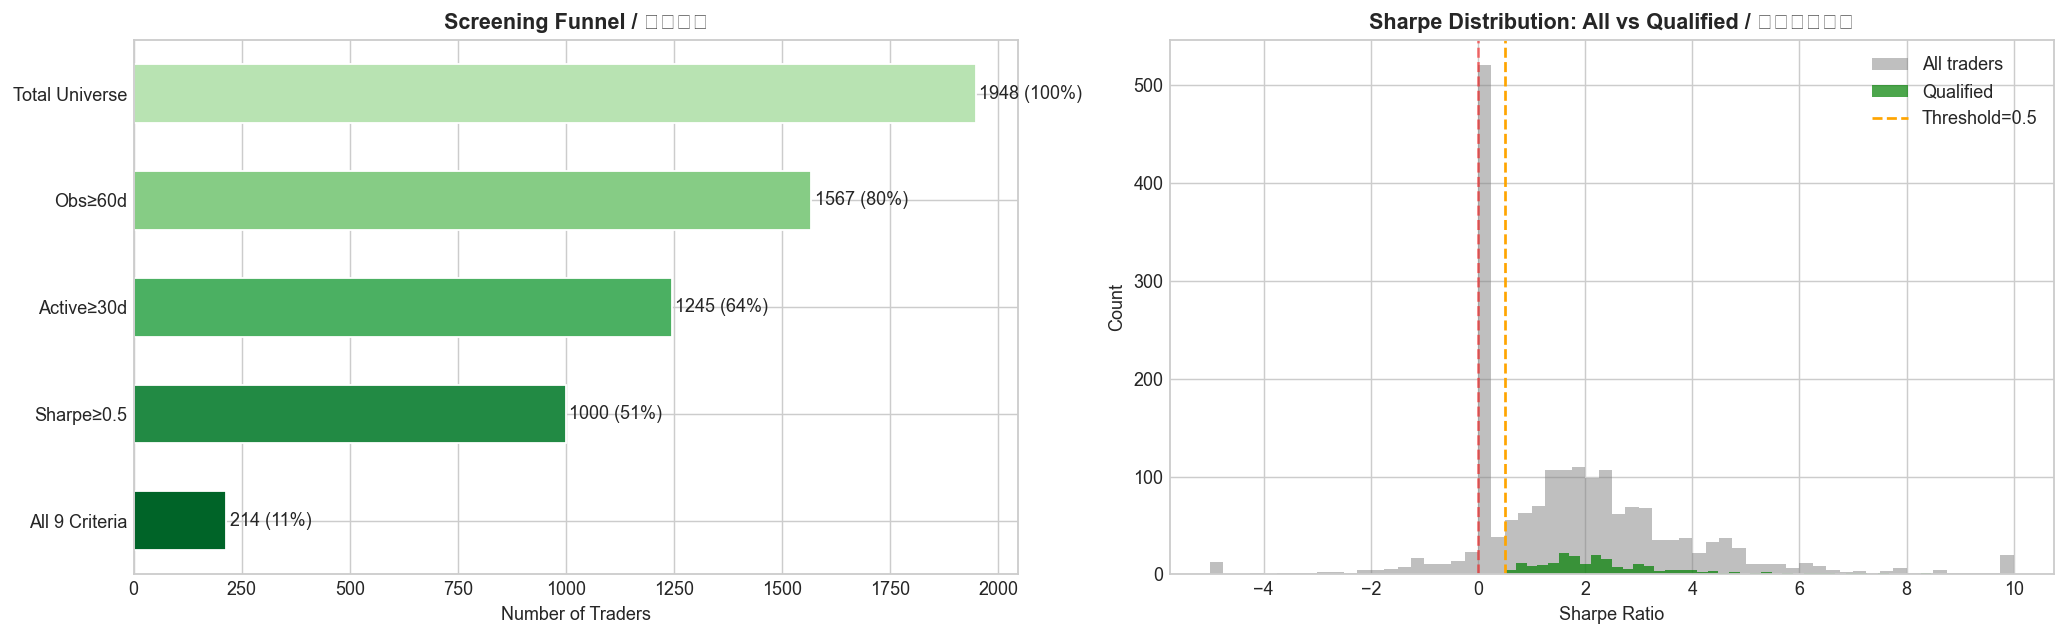

In [6]:
# ── Screening visualization: Funnel + Sharpe comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Funnel chart
stages = ["Total Universe", "Obs≥60d", "Active≥30d", "Sharpe≥0.5", "All 9 Criteria"]
counts = [len(features),
          int(masks["obs_period"].sum()),
          int((masks["obs_period"] & masks["active_days"]).sum()),
          int((masks["obs_period"] & masks["active_days"] & masks["sharpe"]).sum()),
          len(qualified)]
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(stages)))
bars = axes[0].barh(range(len(stages)), counts, color=colors, edgecolor="white", height=0.55)
axes[0].set_yticks(range(len(stages))); axes[0].set_yticklabels(stages)
axes[0].invert_yaxis(); axes[0].set_xlabel("Number of Traders")
axes[0].set_title("Screening Funnel / 筛选漏斗", fontweight="bold")
for bar, c in zip(bars, counts):
    axes[0].text(bar.get_width()+8, bar.get_y()+bar.get_height()/2,
                 f"{c} ({c/len(features)*100:.0f}%)", va="center", fontsize=10)

# Sharpe: all vs qualified
axes[1].hist(features["sharpe"].clip(-5, 10), bins=60, alpha=0.5, color="gray", label="All traders")
axes[1].hist(qualified["sharpe"].clip(-5, 10), bins=40, alpha=0.7, color="green", label="Qualified")
axes[1].axvline(0, color="red", ls="--", alpha=0.5)
axes[1].axvline(SCREEN["min_sharpe"], color="orange", ls="--", label=f"Threshold={SCREEN['min_sharpe']}")
axes[1].set_xlabel("Sharpe Ratio"); axes[1].set_ylabel("Count")
axes[1].set_title("Sharpe Distribution: All vs Qualified / 夏普比率分布", fontweight="bold")
axes[1].legend()
plt.tight_layout(); plt.show()

---
## Stage 4 · Classification: Style Clustering + Performance Tiering / 分类：风格聚类 + 表现分层

**Core Logic / 核心逻辑：**

Traders are organized along **two dimensions** — this is key to building a diversified and manageable portfolio:

交易员按**两个维度**组织——这是构建分散化、可管理组合的关键：

### Dimension 1: Style Clusters (Horizontal) / 风格聚类（横向）
**K-Means clustering** on behavioral features (volatility, autocorrelation, skewness, kurtosis, win rate, activity rate, consistency). This groups traders with **similar trading behavior** together.

**为什么分风格？** Different styles (trend-following vs. mean-reversion, high-vol vs. low-vol) tend to have **low correlation** with each other. By ensuring our portfolio contains traders from **multiple clusters**, we reduce the risk of all positions losing simultaneously.

**为什么不是按资产分类？** We don't have per-asset trade data. But behavioral clustering achieves a similar diversification effect, because traders with different return profiles naturally trade differently.

### Dimension 2: Performance Tiers (Vertical) / 表现分层（纵向）
Traders are ranked by **composite score** and assigned to tiers:

| Tier | % of Qualified | Role in Portfolio |
|------|---------------|-------------------|
| **Core** / 核心 | Top 30% | Portfolio backbone — receive 60% of capital. Highest quality, most consistent. |
| **Satellite** / 卫星 | Next 40% | Return enhancement — receive 30% of capital. Higher risk/reward. |
| **Watch** / 观察 | Bottom 30% | Not allocated. Monitored for promotion as more data accumulates. |

**Composite Score Formula / 综合评分公式：**

```
Score = 0.25×rank(Sharpe) + 0.15×rank(Sortino) + 0.10×rank(Calmar) 
      + 0.15×rank(ProfitFactor) + 0.15×rank(Consistency) 
      + 0.10×rank(WinRate) + 0.10×rank(TailRatio)
```

This multi-factor scoring avoids over-reliance on any single metric. / 多因子评分避免过度依赖单一指标。

In [7]:
# ── Style clustering (K-Means on behavioral features) ──
STYLE_COLS = ["daily_vol","return_autocorr","skewness","kurtosis","win_rate","tail_ratio","activity_rate","sharpe_stability"]
X = qualified[STYLE_COLS].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)

N_CLUSTERS = 4
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
qualified["cluster"] = km.fit_predict(X_scaled)

# Label clusters by comparing to population median
pop_med = qualified[STYLE_COLS].median()
for c in range(N_CLUSTERS):
    cdf = qualified[qualified["cluster"] == c][STYLE_COLS].mean()
    traits = []
    if cdf["daily_vol"] > pop_med["daily_vol"] * 1.5: traits.append("high_vol")
    elif cdf["daily_vol"] < pop_med["daily_vol"] * 0.6: traits.append("low_vol")
    if cdf["return_autocorr"] > 0.08: traits.append("trend")
    elif cdf["return_autocorr"] < -0.08: traits.append("mean_rev")
    if cdf["win_rate"] > pop_med["win_rate"] * 1.1: traits.append("high_wr")
    if cdf["sharpe_stability"] < pop_med["sharpe_stability"] * 0.7: traits.append("stable")
    elif cdf["sharpe_stability"] > pop_med["sharpe_stability"] * 1.5: traits.append("erratic")
    if not traits: traits.append("balanced")
    qualified.loc[qualified["cluster"] == c, "cluster_label"] = "_".join(traits)

# ── Performance tiering ──
score_rank = qualified["composite_score"].rank(pct=True)
qualified["tier"] = "watch"
qualified.loc[score_rank >= 0.70, "tier"] = "core"
qualified.loc[(score_rank >= 0.30) & (score_rank < 0.70), "tier"] = "satellite"

# Summary
print("── Classification Results ──\n")
for tier in ["core","satellite","watch"]:
    t = qualified[qualified["tier"]==tier]
    print(f"  {tier.upper():10s}: {len(t):3d} traders | avg Sharpe={t['sharpe'].mean():.2f} | avg Score={t['composite_score'].mean():.3f}")
print()
for c in sorted(qualified["cluster"].unique()):
    cdf = qualified[qualified["cluster"]==c]
    label = cdf["cluster_label"].iloc[0]
    print(f"  Cluster {c} ({label}): {len(cdf)} traders, Sharpe={cdf['sharpe'].mean():.2f}, Vol={cdf['daily_vol'].mean():.4f}")

── Classification Results ──

  CORE      :  65 traders | avg Sharpe=4.10 | avg Score=0.748
  SATELLITE :  86 traders | avg Sharpe=2.19 | avg Score=0.498
  WATCH     :  63 traders | avg Sharpe=1.22 | avg Score=0.255

  Cluster 0 (high_vol): 26 traders, Sharpe=1.83, Vol=0.1490
  Cluster 1 (balanced): 161 traders, Sharpe=2.46, Vol=0.0554
  Cluster 2 (high_wr_erratic): 26 traders, Sharpe=3.30, Vol=0.0428
  Cluster 3 (high_vol_trend_stable): 1 traders, Sharpe=2.98, Vol=0.4407


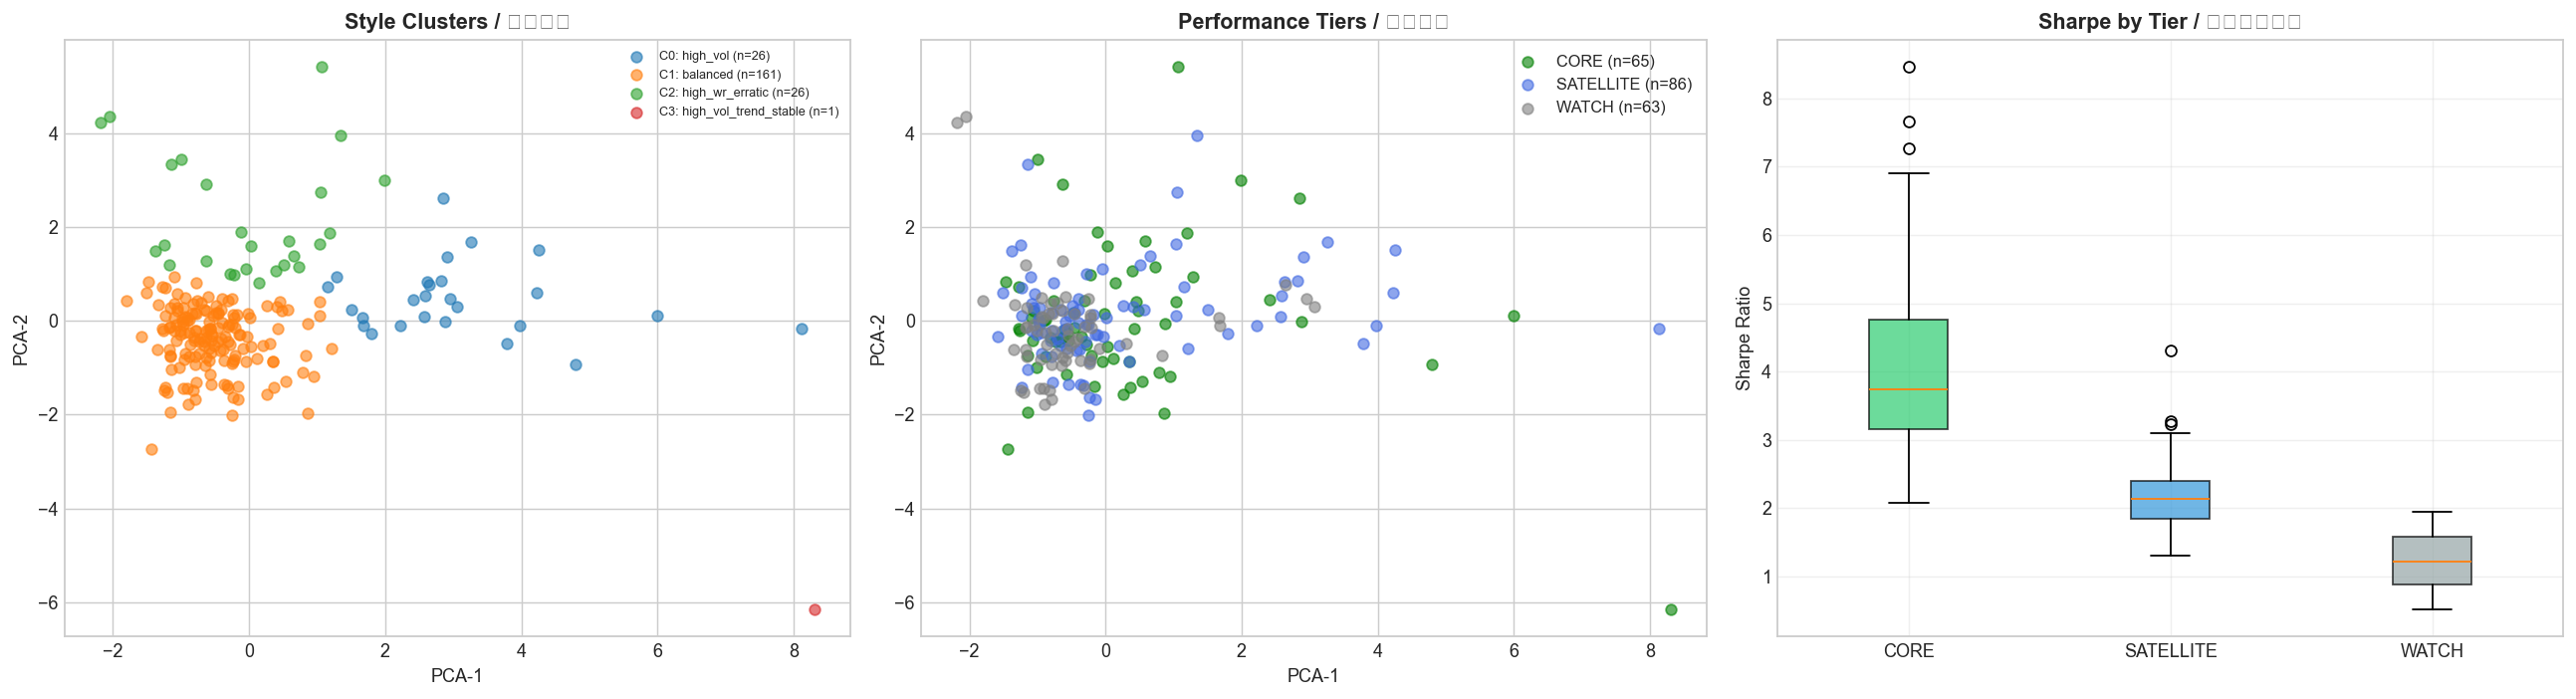

In [8]:
# ── Visualization: PCA scatter (clusters + tiers) + Tier box plots ──
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
qualified["pca1"], qualified["pca2"] = pca_coords[:,0], pca_coords[:,1]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# (a) PCA by cluster
ax = axes[0]
for c in sorted(qualified["cluster"].unique()):
    m = qualified["cluster"] == c
    label = qualified.loc[m, "cluster_label"].iloc[0]
    ax.scatter(qualified.loc[m,"pca1"], qualified.loc[m,"pca2"], alpha=0.6, s=35,
               label=f"C{c}: {label} (n={m.sum()})")
ax.set_xlabel("PCA-1"); ax.set_ylabel("PCA-2")
ax.set_title("Style Clusters / 风格聚类", fontweight="bold"); ax.legend(fontsize=7)

# (b) PCA by tier
ax = axes[1]
tier_colors = {"core":"green","satellite":"royalblue","watch":"gray"}
for tier, color in tier_colors.items():
    m = qualified["tier"] == tier
    ax.scatter(qualified.loc[m,"pca1"], qualified.loc[m,"pca2"], alpha=0.6, s=35,
               c=color, label=f"{tier.upper()} (n={m.sum()})")
ax.set_xlabel("PCA-1"); ax.set_ylabel("PCA-2")
ax.set_title("Performance Tiers / 表现分层", fontweight="bold"); ax.legend(fontsize=9)

# (c) Box plots: Sharpe by tier
ax = axes[2]
tier_order = ["core","satellite","watch"]
data = [qualified[qualified["tier"]==t]["sharpe"].values for t in tier_order]
bp = ax.boxplot(data, labels=[t.upper() for t in tier_order], patch_artist=True)
for patch, color in zip(bp["boxes"], ["#2ecc71","#3498db","#95a5a6"]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Sharpe by Tier / 各层夏普分布", fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Stage 5 · Capital Allocation / 资金分配

**Core Logic / 核心逻辑：**

Allocation follows a **two-level hierarchy** / 资金分配采用**两级层次结构**：

### Level 1: Tier Budget / 层级预算
| Tier | Budget | Rationale |
|------|--------|-----------|
| Core / 核心 | 60% | Backbone — highest confidence traders / 最高置信度的交易员 |
| Satellite / 卫星 | 30% | Enhancement — promising but less proven / 有潜力但验证不足 |
| Cash Reserve / 现金 | 10% | Margin buffer + dry powder for opportunities / 保证金缓冲+机会储备 |

### Level 2: Within-Tier Weighting / 层内分配
$$w_i = \frac{\text{score}_i \;/\; \text{vol}_i}{\sum_j (\text{score}_j \;/\; \text{vol}_j)}$$

This **score/volatility** ratio rewards traders who are both high-quality AND low-risk. A high-Sharpe but volatile trader gets less capital than a high-Sharpe low-volatility one.

**score/volatility** 比率奖励**高质量且低风险**的交易员。高夏普但高波动的交易员获得的资金少于高夏普低波动的交易员。

### Concentration Constraints / 集中度约束
These are **iteratively enforced** (not just clipped once, which re-normalization would undo):

这些约束**迭代执行**（非仅裁剪一次，否则重新归一化会撤销约束）：

- **Single trader cap: 10%** — no single point of failure / 无单一故障点
- **Cluster cap: 40%** — prevents style concentration / 防止风格集中
- **Correlation deduction** — reduce weight of highly correlated pairs (ρ > 0.7) / 降低高相关交易对权重

In [9]:
# ── Capital allocation ──
TOTAL_CAPITAL    = 100_000
CORE_BUDGET      = 0.60
SAT_BUDGET       = 0.30
CASH_RESERVE     = 0.10
MAX_SINGLE       = 0.10   # per-trader cap
MAX_CLUSTER      = 0.40   # per-cluster cap
TOTAL_BUDGET     = CORE_BUDGET + SAT_BUDGET  # 90%

allocated = qualified[qualified["tier"].isin(["core","satellite"])].copy()
allocated["weight"] = 0.0

# Step 1: Score/volatility weighted within each tier
for tier, budget in [("core", CORE_BUDGET), ("satellite", SAT_BUDGET)]:
    m = allocated["tier"] == tier
    scores = allocated.loc[m, "composite_score"]
    vols   = allocated.loc[m, "daily_vol"].clip(lower=1e-6)
    raw_w  = (scores / vols); raw_w = raw_w.clip(lower=0)
    allocated.loc[m, "weight"] = raw_w / raw_w.sum() * budget

# Step 2: Iterative constraint enforcement
for _ in range(20):
    changed = False
    # Cluster cap
    for c in allocated["cluster"].unique():
        cm = allocated["cluster"] == c
        cw = allocated.loc[cm, "weight"].sum()
        if cw > MAX_CLUSTER + 1e-6:
            allocated.loc[cm, "weight"] *= MAX_CLUSTER / cw
            changed = True
    # Single trader cap
    over = allocated["weight"] > MAX_SINGLE + 1e-6
    if over.any():
        allocated.loc[over, "weight"] = MAX_SINGLE
        changed = True
    # Re-distribute
    cur = allocated["weight"].sum()
    if cur > 0 and abs(cur - TOTAL_BUDGET) > 1e-6:
        at_cap = (allocated["weight"] >= MAX_SINGLE - 1e-6)
        for c in allocated["cluster"].unique():
            cm = allocated["cluster"] == c
            if allocated.loc[cm, "weight"].sum() >= MAX_CLUSTER - 1e-6:
                at_cap |= cm
        free = ~at_cap
        if free.any():
            deficit = TOTAL_BUDGET - cur
            allocated.loc[free, "weight"] *= (1 + deficit / allocated.loc[free, "weight"].sum())
            changed = True
        else:
            allocated["weight"] = allocated["weight"] / cur * TOTAL_BUDGET
    if not changed: break

# Final normalize
cur = allocated["weight"].sum()
if abs(cur - TOTAL_BUDGET) > 1e-4:
    allocated["weight"] = allocated["weight"] / cur * TOTAL_BUDGET

allocated["dollar"] = allocated["weight"] * TOTAL_CAPITAL

# ── Results ──
print(f"Traders allocated: {len(allocated)}")
print(f"Total weight     : {allocated['weight'].sum():.2%} (+ {CASH_RESERVE:.0%} cash = 100%)")
print(f"\n── Tier breakdown ──")
for tier in ["core","satellite"]:
    t = allocated[allocated["tier"]==tier]
    print(f"  {tier.upper():10s}: {len(t):3d} traders | weight={t['weight'].sum():.2%} | avg=${t['dollar'].mean():,.0f}")
print(f"\n── Cluster breakdown ──")
for c in sorted(allocated["cluster"].unique()):
    cd = allocated[allocated["cluster"]==c]
    print(f"  C{c} ({cd['cluster_label'].iloc[0]}): {len(cd)} traders, weight={cd['weight'].sum():.2%}")
print(f"\n── Concentration ──")
print(f"  Max single trader: {allocated['weight'].max():.2%}")
print(f"  Top-5 weight     : {allocated.nlargest(5,'weight')['weight'].sum():.2%}")
print(f"  Herfindahl index : {(allocated['weight']**2).sum():.4f}")

Traders allocated: 151
Total weight     : 90.00% (+ 10% cash = 100%)

── Tier breakdown ──
  CORE      :  65 traders | weight=58.75% | avg=$904
  SATELLITE :  86 traders | weight=31.25% | avg=$363

── Cluster breakdown ──
  C0 (high_vol): 21 traders, weight=9.88%
  C1 (balanced): 107 traders, weight=40.00%
  C2 (high_wr_erratic): 22 traders, weight=40.00%
  C3 (high_vol_trend_stable): 1 traders, weight=0.12%

── Concentration ──
  Max single trader: 8.13%
  Top-5 weight     : 31.01%
  Herfindahl index : 0.0261


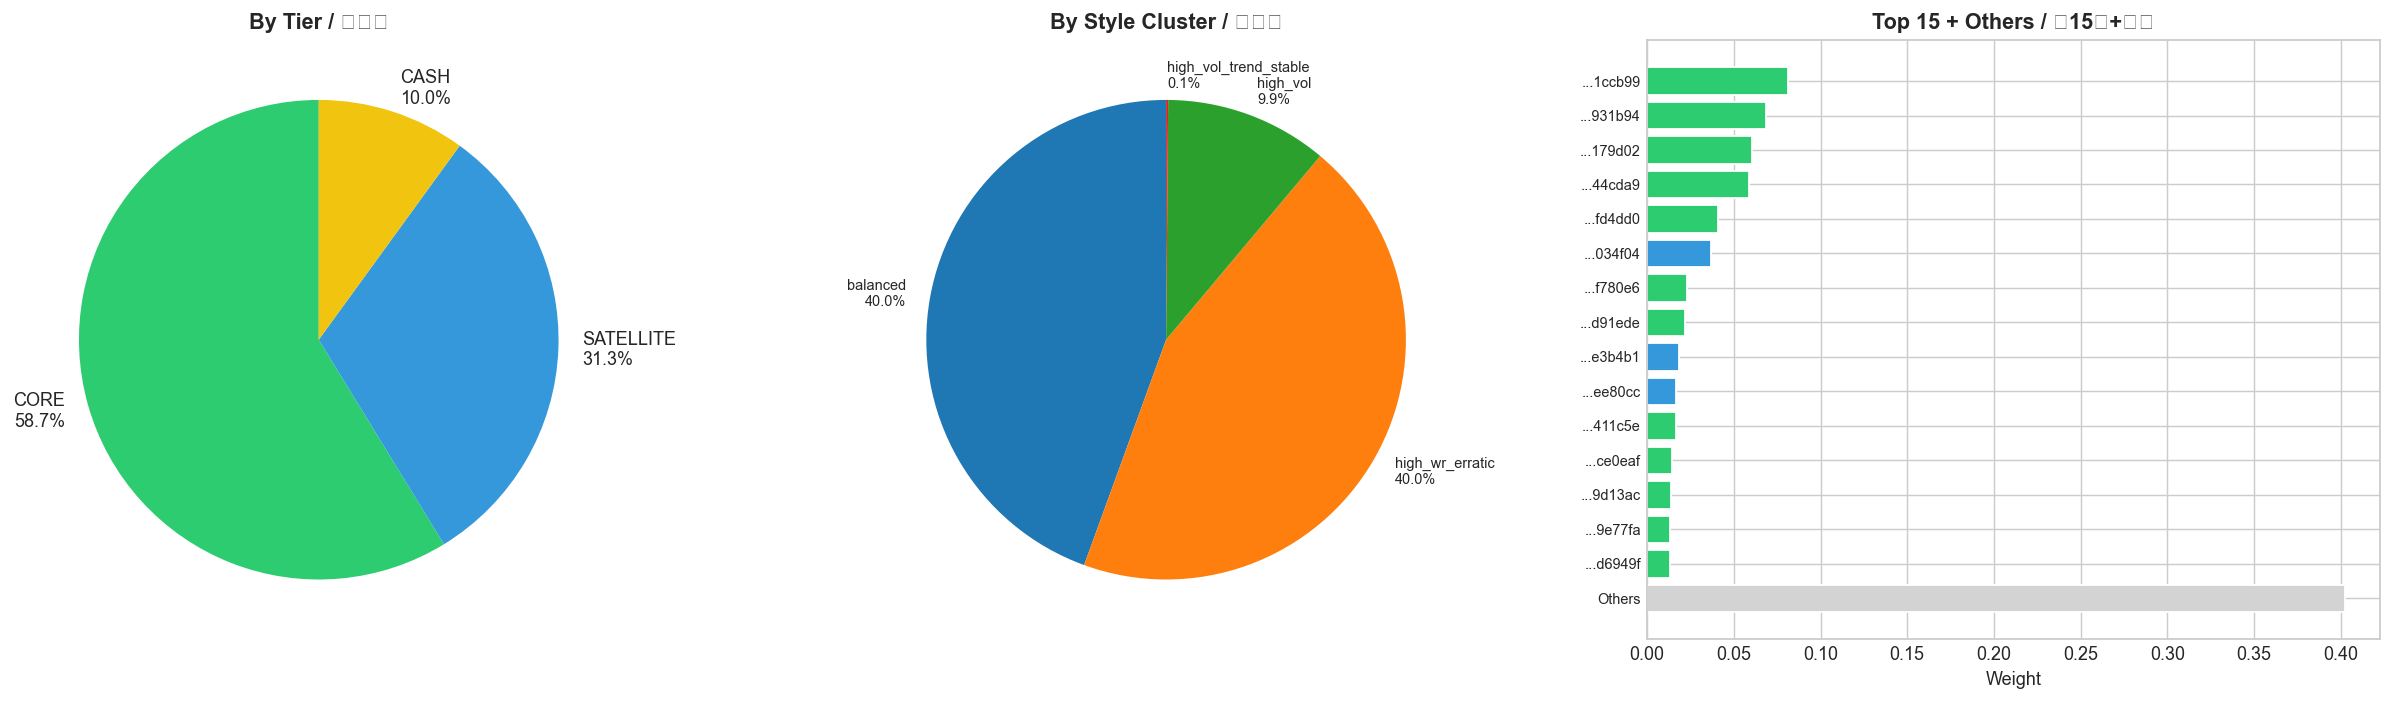


── Top 10 Allocated Traders ──


,tier,cluster_label,weight,dollar,sharpe,max_drawdown,win_rate,composite_score
...a9f41ccb99,core,balanced,8.13%,"$8,126",3.190324,-0.005798,0.638889,0.685047
...337d931b94,core,high_wr_erratic,6.85%,"$6,853",7.658028,-0.046879,0.642857,0.771729
...89c8179d02,core,high_wr_erratic,6.08%,"$6,076",7.260774,-0.042189,0.678571,0.785514
...2ad744cda9,core,high_wr_erratic,5.88%,"$5,881",4.588217,-0.005000,0.567568,0.799065
...b48ffd4dd0,core,balanced,4.07%,"$4,072",4.801020,-0.008201,0.674419,0.933645
...4968034f04,satellite,high_wr_erratic,3.71%,"$3,711",3.234259,-0.177290,0.735955,0.564019
...44c3f780e6,core,high_wr_erratic,2.29%,"$2,288",3.404268,-0.086562,0.544944,0.645561
...f408d91ede,core,high_wr_erratic,2.18%,"$2,178",5.390868,-0.090511,0.680000,0.800701
...5493e3b4b1,satellite,high_wr_erratic,1.82%,"$1,819",2.335055,-0.152747,0.730337,0.611682
...8c93ee80cc,satellite,high_vol,1.66%,"$1,660",1.793647,-0.220462,0.522472,0.625000


In [10]:
# ── Allocation visualization: Pie + Top traders ──
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# (a) By Tier
ax = axes[0]
tw = allocated.groupby("tier")["weight"].sum()
sizes = [tw.get("core",0), tw.get("satellite",0), CASH_RESERVE]
labels= [f"CORE\n{sizes[0]:.1%}", f"SATELLITE\n{sizes[1]:.1%}", f"CASH\n{sizes[2]:.1%}"]
ax.pie(sizes, labels=labels, colors=["#2ecc71","#3498db","#f1c40f"],
       startangle=90, textprops={"fontsize":10})
ax.set_title("By Tier / 按层级", fontweight="bold")

# (b) By Cluster
ax = axes[1]
cw = allocated.groupby("cluster_label")["weight"].sum().sort_values(ascending=False)
ax.pie(cw, labels=[f"{l}\n{w:.1%}" for l,w in cw.items()], startangle=90, textprops={"fontsize":8})
ax.set_title("By Style Cluster / 按风格", fontweight="bold")

# (c) Top 15 traders bar
ax = axes[2]
top = allocated.nlargest(15, "weight")
other_w = allocated["weight"].sum() - top["weight"].sum()
labels = [f"...{t[-6:]}" for t in top.index] + ["Others"]
vals = list(top["weight"].values) + [other_w]
colors = ["#2ecc71" if allocated.loc[t,"tier"]=="core" else "#3498db" for t in top.index] + ["lightgray"]
ax.barh(range(len(labels)), vals, color=colors, edgecolor="white")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis(); ax.set_xlabel("Weight")
ax.set_title("Top 15 + Others / 前15名+其余", fontweight="bold")
plt.tight_layout(); plt.show()

# ── Top-10 table ──
print("\n── Top 10 Allocated Traders ──")
top10 = allocated.nlargest(10, "weight")[["tier","cluster_label","weight","dollar","sharpe","max_drawdown","win_rate","composite_score"]].copy()
top10.index = [f"...{t[-10:]}" for t in top10.index]
top10["weight"] = top10["weight"].map("{:.2%}".format)
top10["dollar"] = top10["dollar"].map("${:,.0f}".format)
display(top10)

---
## Stage 6 · Backtest Simulation with Risk Management / 回测模拟与风控

Core Logic / 核心逻辑：

回测模拟**逐日组合执行**，在每一步应用**风控**，包含收益率计算和真实的风险管理操作。

### Risk Control Layers / 风控层级

| Layer | Mechanism | Threshold | Action |
|-------|-----------|-----------|--------|
| **Per-Trader** | Trailing stop-loss / 跟踪止损 | -15% from peak | Halt following + 14-day cooldown, re-enter at 50% weight / 暂停+14天冷却+半仓回归 |
| **Per-Trader** | Drawdown reduction / 回撤减仓 | -8% from peak | Reduce to 50% of initial weight / 降至初始仓位的50% |
| **Portfolio** | Circuit breaker / 熔断机制 | -10% portfolio DD | All positions halved / 全部仓位减半 |
| **Portfolio** | Daily loss limit / 日损限制 | -3% daily | Alert for manual review / 告警人工审查 |
| **Structural** | Cluster cap | 40% | Hard cap on allocation / 硬性上限 |
| **Structural** | Single trader cap | 10% | Hard cap on allocation / 硬性上限 |


- **-15% per-trader stop**: Limits the damage from a single trader's edge deteriorating. The cooldown prevents whipsawing back in too quickly.
- **-10% portfolio DD**: A circuit breaker appropriate for a grayscale trial — preserves capital for re-deployment after investigation.
- **14-day cooldown + 50% re-entry**: Gradual recovery avoids full re-commitment to a possibly broken signal.

### Walk-Forward Validation / 前推验证

We split the data 60/40 (in-sample / out-of-sample) to test if decisions made on historical data hold up. **If OOS Sharpe collapses, the strategy is overfit.** / 如果样本外夏普崩塌，说明策略过拟合。

In [11]:
# ── Build return panel & run portfolio simulation ──
calendar = pd.date_range(raw["date"].min(), raw["date"].max(), freq="D")
return_panel = raw.pivot_table(index="date", columns="trader", values="daily_return", aggfunc="first")
return_panel = return_panel.reindex(calendar)

# Risk parameters
STOP_LOSS       = -0.15
PORT_MAX_DD     = -0.10
DD_REDUCE_THR   = -0.08
DD_REDUCE_FAC   = 0.50
TX_COST_BPS     = 8.0
REBAL_DAYS      = 7
COOLDOWN        = 14

def simulate_portfolio(ret_panel, traders, weights_dict, start=None, end=None):
    """Day-by-day portfolio simulation with per-trader stop-loss and portfolio circuit breaker."""
    panel = ret_panel[traders].copy()
    if start: panel = panel[panel.index >= start]
    if end:   panel = panel[panel.index <= end]
    panel = panel.fillna(0.0)

    n_days = len(panel)
    w = np.array([weights_dict.get(t, 0.0) for t in traders])
    w0 = w.copy()
    tc = TX_COST_BPS / 10000.0

    port_eq  = np.ones(n_days)
    port_ret = np.zeros(n_days)
    n_active = np.zeros(n_days, dtype=int)
    cum_ret  = np.zeros(len(traders))
    peak_eq  = np.ones(len(traders))
    stop_day = np.full(len(traders), -9999, dtype=int)
    port_val, port_peak = 1.0, 1.0
    n_stops = 0

    for i in range(n_days):
        day_ret = 0.0
        active = 0
        for j in range(len(traders)):
            # Cooldown check
            if stop_day[j] > -9999:
                if i - stop_day[j] < COOLDOWN:
                    w[j] = 0.0; continue
                else:
                    stop_day[j] = -9999; w[j] = w0[j] * 0.5
                    cum_ret[j] = 0.0; peak_eq[j] = 1.0

            r = panel.iloc[i, j]
            cum_ret[j] += r
            teq = 1.0 + cum_ret[j]
            if teq > peak_eq[j]: peak_eq[j] = teq
            tdd = (teq - peak_eq[j]) / peak_eq[j] if peak_eq[j] > 0 else 0.0

            if tdd < STOP_LOSS:
                stop_day[j] = i; w[j] = 0.0; n_stops += 1; continue
            elif tdd < DD_REDUCE_THR:
                w[j] = w0[j] * DD_REDUCE_FAC

            day_ret += w[j] * r
            active += 1

        # Transaction cost on rebalance days
        if REBAL_DAYS > 0 and i > 0 and i % REBAL_DAYS == 0:
            day_ret -= sum(abs(w[j]) * tc for j in range(len(traders))) * 0.1  # partial turnover

        port_val *= (1 + day_ret)
        if port_val > port_peak: port_peak = port_val
        pdd = (port_val - port_peak) / port_peak
        if pdd < PORT_MAX_DD:
            w *= 0.5  # circuit breaker

        port_eq[i] = port_val; port_ret[i] = day_ret; n_active[i] = active

    return pd.Series(port_eq, index=panel.index), pd.Series(port_ret, index=panel.index), n_active, n_stops

# Run full backtest
traders_list = allocated.index.tolist()
weights_dict = allocated["weight"].to_dict()
avail = [t for t in traders_list if t in return_panel.columns]
eq_full, ret_full, active_full, stops_full = simulate_portfolio(return_panel, avail, weights_dict)

# Walk-forward split
split_idx = int(len(calendar) * 0.6)
split_date = calendar[split_idx]
eq_is, ret_is, _, stops_is   = simulate_portfolio(return_panel, avail, weights_dict, end=split_date)
eq_oos, ret_oos, _, stops_oos = simulate_portfolio(return_panel, avail, weights_dict, start=split_date)

def calc_metrics(eq, ret):
    n = len(ret); v = ret.values; v = v[~np.isnan(v)]
    total  = eq.iloc[-1]/eq.iloc[0] - 1
    ann_r  = (1+total)**(ANN/n) - 1
    vol    = v.std(ddof=1)*np.sqrt(ANN)
    sharpe = v.mean()/v.std(ddof=1)*np.sqrt(ANN) if v.std()>1e-10 else 0
    pk     = np.maximum.accumulate(eq.values)
    dd     = (eq.values - pk)/pk
    maxdd  = dd.min()
    wr     = (v>0).sum()/len(v)
    return dict(total=total, ann_ret=ann_r, vol=vol, sharpe=sharpe, max_dd=maxdd, win_rate=wr)

m_full = calc_metrics(eq_full, ret_full)
m_is   = calc_metrics(eq_is, ret_is)
m_oos  = calc_metrics(eq_oos, ret_oos)

print("═"*70)
print(f"{'':20s} {'FULL':>12s} {'IN-SAMPLE':>12s} {'OUT-OF-SAMPLE':>14s}")
print("─"*70)
for k in ["total","ann_ret","vol","sharpe","max_dd","win_rate"]:
    fmt = "{:.2%}" if k != "sharpe" else "{:.2f}"
    print(f"  {k:18s} {fmt.format(m_full[k]):>12s} {fmt.format(m_is[k]):>12s} {fmt.format(m_oos[k]):>14s}")
print(f"  {'stop_loss_events':18s} {stops_full:>12d} {stops_is:>12d} {stops_oos:>14d}")
print("═"*70)

══════════════════════════════════════════════════════════════════════
                             FULL    IN-SAMPLE  OUT-OF-SAMPLE
──────────────────────────────────────────────────────────────────────
  total                    45.88%       30.89%         13.26%
  ann_ret                 115.96%      148.37%         87.96%
  vol                       9.90%       12.22%          4.89%
  sharpe                     7.84         7.51          12.98
  max_dd                   -0.18%       -0.17%         -0.21%
  win_rate                 84.36%       87.04%         84.72%
  stop_loss_events            203          140            102
══════════════════════════════════════════════════════════════════════


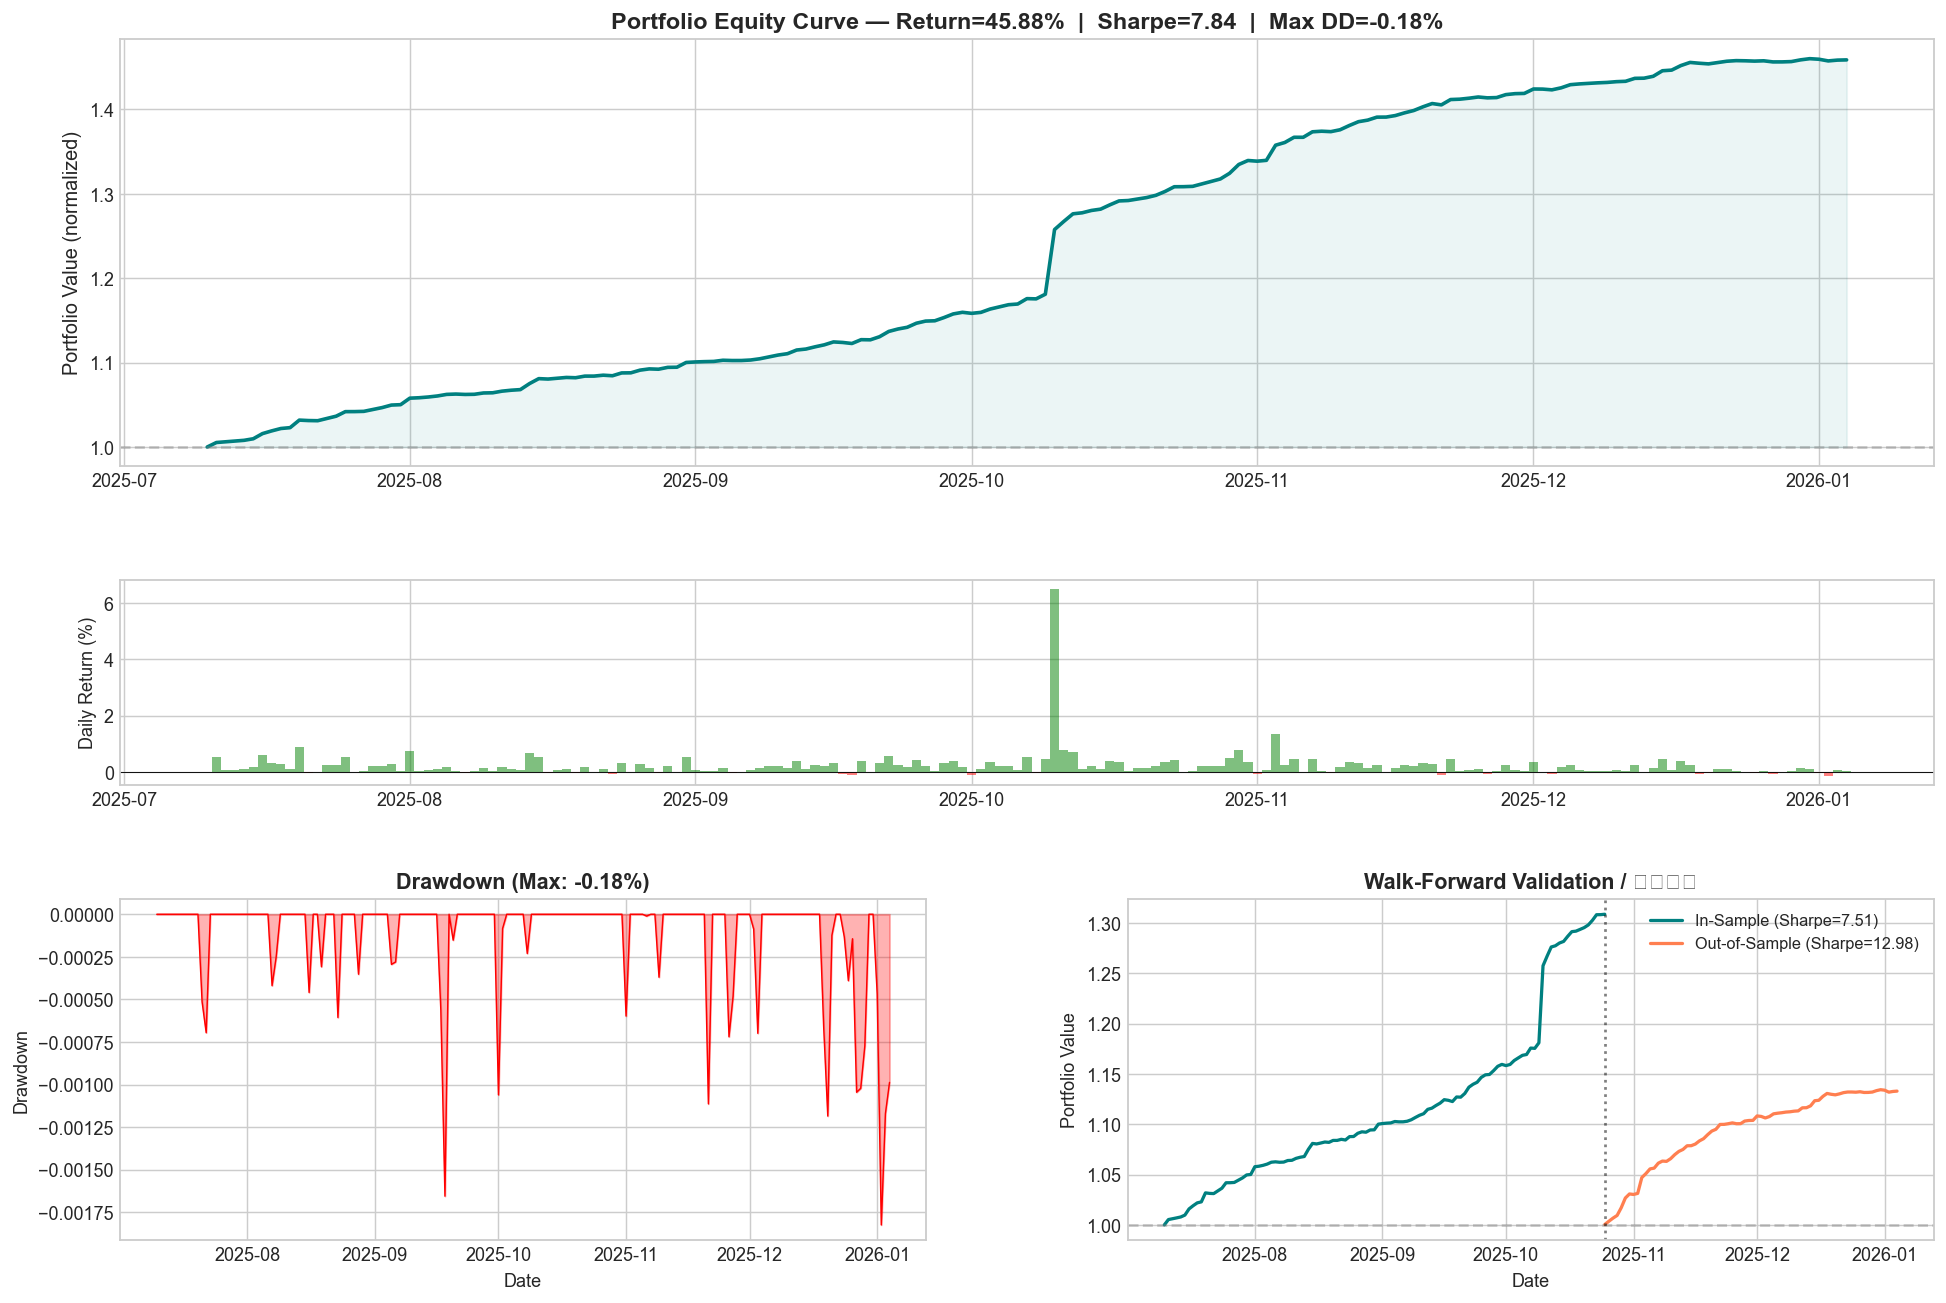

In [12]:
# ── Main result charts: Equity + Drawdown + Walk-Forward ──
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 2, height_ratios=[2.5, 1.2, 2], hspace=0.35, wspace=0.25)

# (1) Equity curve — full period
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(eq_full.index, eq_full.values, color="teal", lw=2)
ax1.fill_between(eq_full.index, 1, eq_full.values, alpha=0.08, color="teal")
ax1.axhline(1, color="gray", ls="--", alpha=0.4)
ax1.set_ylabel("Portfolio Value (normalized)", fontsize=11)
ax1.set_title(f"Portfolio Equity Curve — Return={m_full['total']:.2%}  |  Sharpe={m_full['sharpe']:.2f}  |  Max DD={m_full['max_dd']:.2%}",
              fontsize=13, fontweight="bold")

# (2) Daily returns
ax2 = fig.add_subplot(gs[1, :], sharex=ax1)
colors = np.where(ret_full.values >= 0, "green", "red")
ax2.bar(ret_full.index, ret_full.values*100, color=colors, alpha=0.5, width=1)
ax2.set_ylabel("Daily Return (%)")
ax2.axhline(0, color="black", lw=0.5)

# (3) Drawdown
ax3 = fig.add_subplot(gs[2, 0])
pk = np.maximum.accumulate(eq_full.values)
dd = (eq_full.values - pk) / pk
ax3.fill_between(eq_full.index, dd, 0, color="red", alpha=0.3)
ax3.plot(eq_full.index, dd, color="red", lw=0.8)
ax3.set_ylabel("Drawdown"); ax3.set_xlabel("Date")
ax3.set_title(f"Drawdown (Max: {dd.min():.2%})", fontweight="bold")

# (4) Walk-forward: IS vs OOS
ax4 = fig.add_subplot(gs[2, 1])
ax4.plot(eq_is.index, eq_is.values, color="teal", lw=1.8, label=f"In-Sample (Sharpe={m_is['sharpe']:.2f})")
ax4.plot(eq_oos.index, eq_oos.values, color="coral", lw=1.8, label=f"Out-of-Sample (Sharpe={m_oos['sharpe']:.2f})")
ax4.axhline(1, color="gray", ls="--", alpha=0.4)
ax4.axvline(split_date, color="black", ls=":", alpha=0.5)
ax4.set_ylabel("Portfolio Value"); ax4.set_xlabel("Date")
ax4.set_title("Walk-Forward Validation / 前推验证", fontweight="bold")
ax4.legend(fontsize=9)
plt.show()

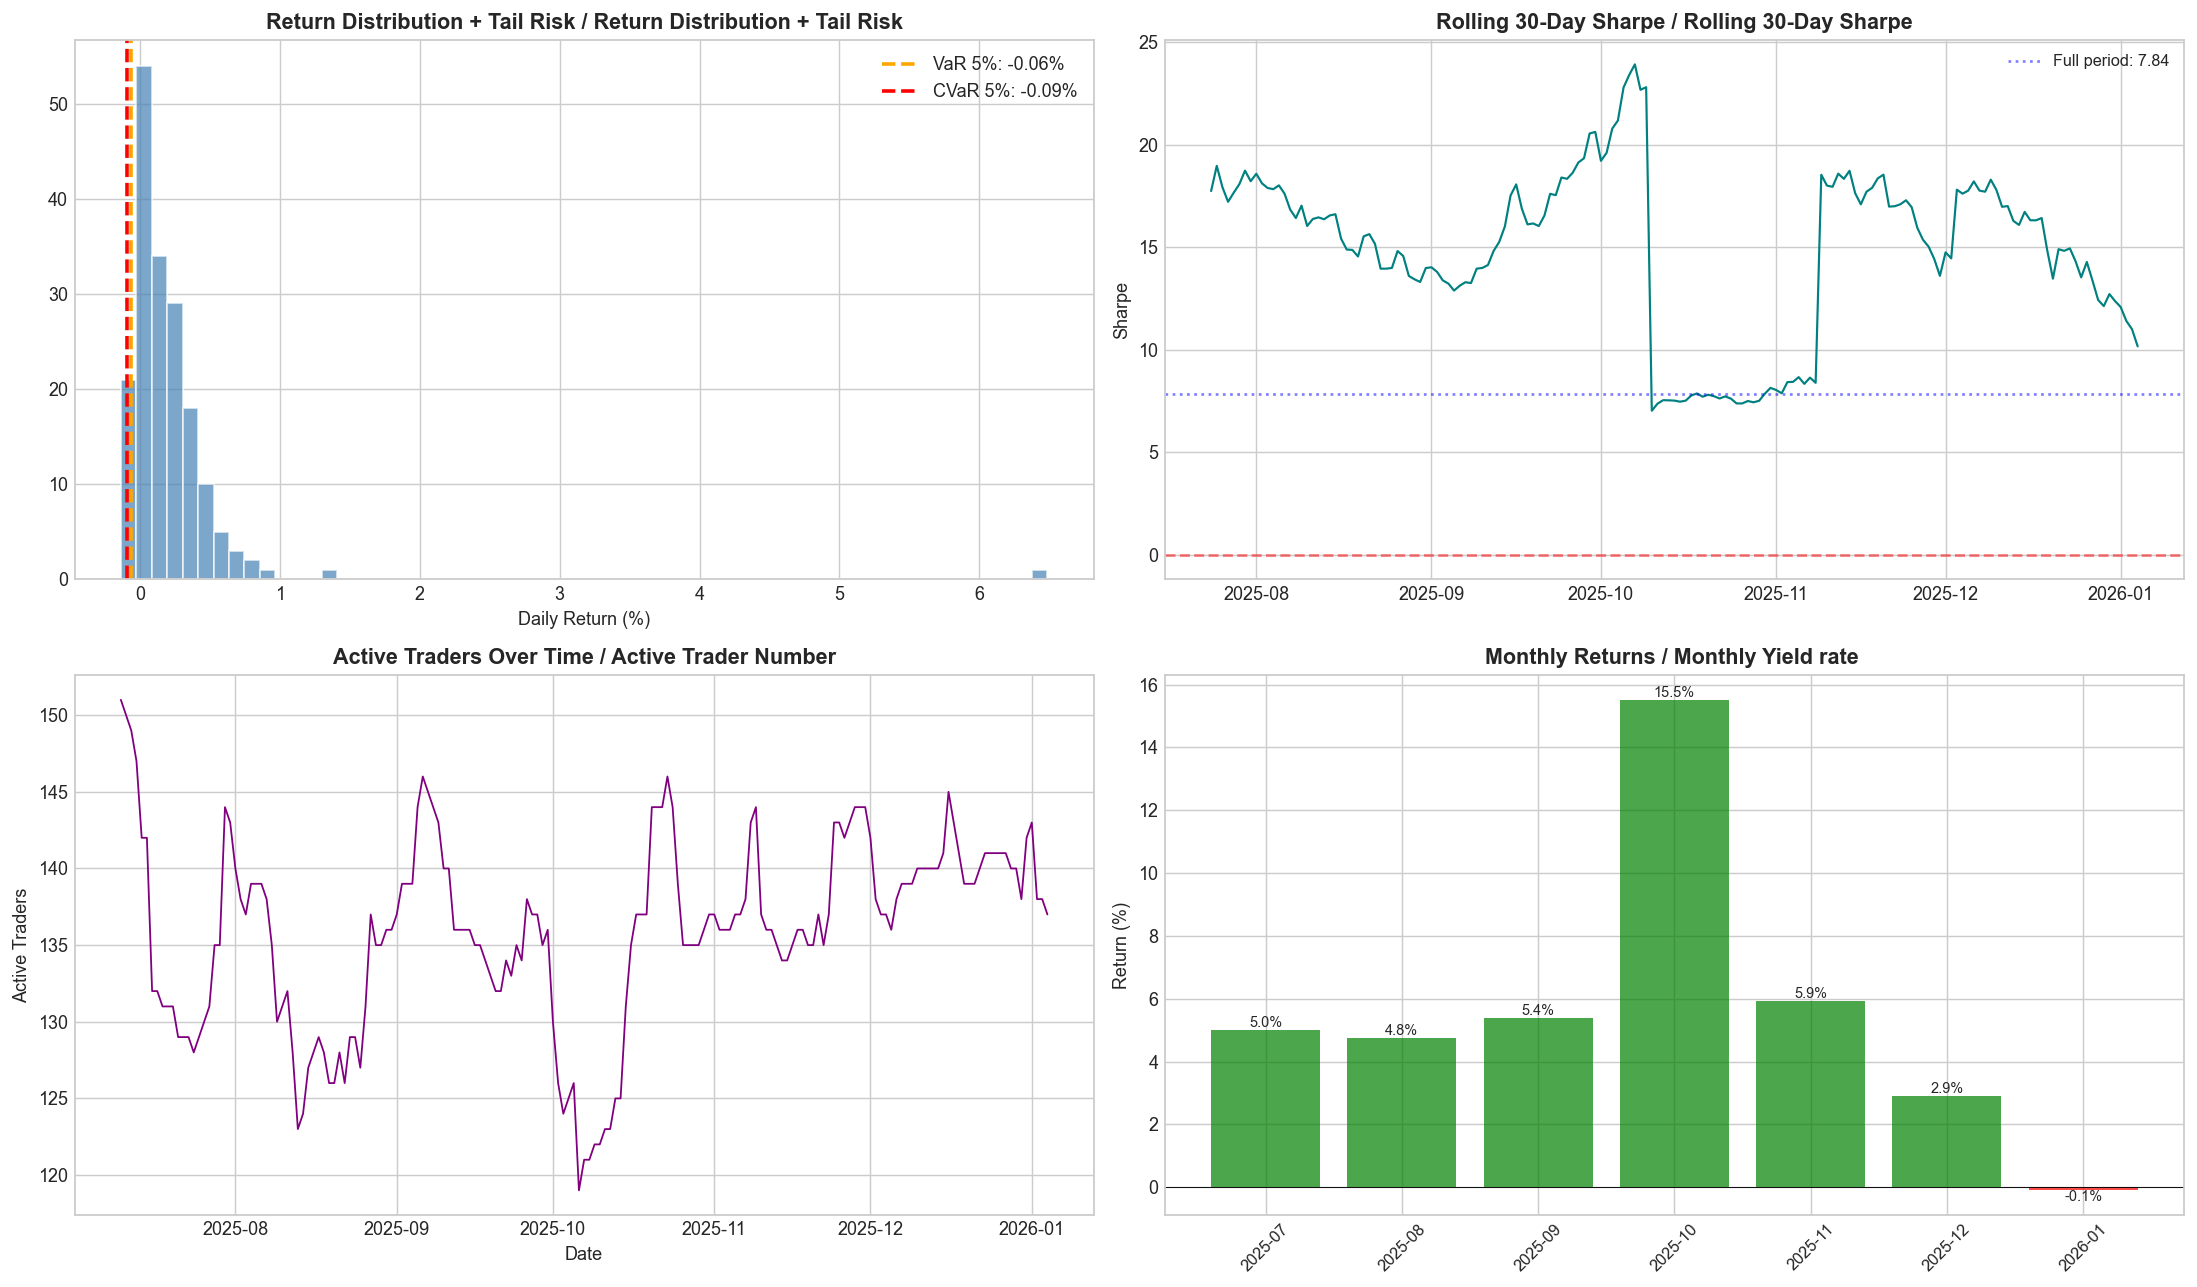

In [13]:
# ── Risk dashboard: Return distribution + Rolling Sharpe + Active traders + Monthly returns ──
fig, axes = plt.subplots(2, 2, figsize=(17, 10))

# (a) Return distribution with VaR/CVaR
ax = axes[0,0]
v = ret_full.values
ax.hist(v*100, bins=60, alpha=0.7, color="steelblue", edgecolor="white")
var5 = np.percentile(v, 5)*100
cvar5 = v[v <= np.percentile(v,5)].mean()*100 if (v <= np.percentile(v,5)).any() else var5
ax.axvline(var5, color="orange", ls="--", lw=2, label=f"VaR 5%: {var5:.2f}%")
ax.axvline(cvar5, color="red", ls="--", lw=2, label=f"CVaR 5%: {cvar5:.2f}%")
ax.set_xlabel("Daily Return (%)"); ax.set_title("Return Distribution + Tail Risk / Return Distribution + Tail Risk", fontweight="bold")
ax.legend()

# (b) Rolling 30-day Sharpe
ax = axes[0,1]
rm = ret_full.rolling(30, min_periods=15).mean()
rs = ret_full.rolling(30, min_periods=15).std()
r_sharpe = (rm / rs * np.sqrt(ANN)).dropna()
ax.plot(r_sharpe.index, r_sharpe.values, color="teal", lw=1.2)
ax.axhline(0, color="red", ls="--", alpha=0.5)
ax.axhline(m_full["sharpe"], color="blue", ls=":", alpha=0.5, label=f"Full period: {m_full['sharpe']:.2f}")
ax.set_ylabel("Sharpe"); ax.set_title("Rolling 30-Day Sharpe / Rolling 30-Day Sharpe", fontweight="bold")
ax.legend(fontsize=9)

# (c) Active traders over time
ax = axes[1,0]
ax.plot(eq_full.index, active_full, color="purple", lw=1)
ax.set_ylabel("Active Traders"); ax.set_xlabel("Date")
ax.set_title("Active Traders Over Time / Active Trader Number", fontweight="bold")

# (d) Monthly returns
ax = axes[1,1]
monthly = ret_full.resample("ME").apply(lambda x: (1+x).prod()-1)
mc = np.where(monthly.values >= 0, "green", "red")
bars = ax.bar(range(len(monthly)), monthly.values*100, color=mc, alpha=0.7)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index.strftime("%Y-%m"), rotation=45, fontsize=9)
ax.set_ylabel("Return (%)"); ax.axhline(0, color="black", lw=0.5)
ax.set_title("Monthly Returns / Monthly Yield rate ", fontweight="bold")
for bar, val in zip(bars, monthly.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
            f"{val*100:.1f}%", ha="center", va="bottom" if val>=0 else "top", fontsize=8)

plt.tight_layout(); plt.show()

---
## Stage 7 · Grayscale Operations & Iteration Plan / 灰度运营与迭代计划

**Core Logic / 核心逻辑：**

A strategy is only as good as its **operational framework**. The following addresses how to **deploy, monitor, and evolve** the portfolio in production.

策略的价值取决于其**运营框架**。以下说明如何在生产环境中**部署、监控和迭代**组合。

### Deployment Phases / 部署阶段

| Phase | Duration | Action | Exit Criteria |
|-------|----------|--------|---------------|
| **Shadow** / 影子 | Week 1-2 | Signal-only, no real capital. Measure signal latency & accuracy. | Tracking error < 5% vs backtest |
| **25% Capital** | Week 3-4 | Deploy 25% capital. Monitor slippage vs. expected. | No circuit breaker trigger; slippage < 10 bps |
| **50% Capital** | Month 2 | Scale up if Phase 2 passes. | Consistent positive Sharpe |
| **Full Deploy** | Month 3+ | 100% capital with weekly rebalance + monthly review. | Ongoing monitoring |

### Monitoring Dashboard / 监控仪表盘

| Metric | Frequency | Alert |
|--------|-----------|-------|
| Portfolio P&L | Real-time | Daily loss > -3% |
| Per-trader DD | Real-time | DD > -15% → auto stop |
| Portfolio DD | Real-time | DD > -10% → circuit breaker |
| Execution slippage | Per-trade | > 10 bps deviation |
| Rolling 30d Sharpe | Weekly | < 0 for 2 weeks |
| Active trader count | Daily | < 50% of initial |
| Pairwise correlation | Weekly | Avg ρ > 0.5 |

### Trader Promotion / Demotion / 升降级规则

- **Promotion** (Watch → Satellite → Core): 30-day rolling Sharpe above threshold, no stop-loss triggers, consistent behavior over 2+ review periods.
- **Demotion** (Core → Satellite → Watch → Remove): 2+ stop-loss triggers within 30 days, sustained Sharpe degradation, or behavioral drift detected.
- **Emergency Removal**: Single-day loss > 30%, or evidence of wash trading / manipulation.

### Handling Performance Non-Persistence / 应对表现不持续

Historical returns **do not guarantee future performance**. Our mitigations:

1. **Walk-forward validation**: We test on out-of-sample data before deployment.
2. **Per-trader stop-loss**: Automatically limits damage when a trader's edge fades.
3. **Diversification**: Multiple clusters + many traders → no single dependency.
4. **Watch list pipeline**: New traders can be promoted as old ones degrade.
5. **Cash reserve**: 10% buffer absorbs shocks without forced liquidation.
6. **Weekly rebalance**: Regular refresh prevents stale allocations.

In [14]:
# ── Final summary output ──
display(HTML(f"""
<div style="background:#f0f8f0; border:2px solid #2ecc71; border-radius:10px; padding:20px; margin:10px 0">
<h2 style="color:#2c3e50; margin-top:0">Final Portfolio Summary / 最终组合概览</h2>
<table style="font-size:14px; border-collapse:collapse; width:100%">
<tr><td style="padding:6px; border-bottom:1px solid #ddd"><b>Universe</b></td>
    <td style="padding:6px; border-bottom:1px solid #ddd">{len(features)} traders evaluated</td></tr>
<tr><td style="padding:6px; border-bottom:1px solid #ddd"><b>Screening</b></td>
    <td style="padding:6px; border-bottom:1px solid #ddd">9 filters → {len(qualified)} qualified ({len(qualified)/len(features)*100:.0f}%)</td></tr>
<tr><td style="padding:6px; border-bottom:1px solid #ddd"><b>Allocated</b></td>
    <td style="padding:6px; border-bottom:1px solid #ddd">{len(allocated)} traders (Core: {(allocated['tier']=='core').sum()}, Satellite: {(allocated['tier']=='satellite').sum()})</td></tr>
<tr><td style="padding:6px; border-bottom:1px solid #ddd"><b>Capital</b></td>
    <td style="padding:6px; border-bottom:1px solid #ddd">${TOTAL_CAPITAL:,} (90% deployed + 10% cash reserve)</td></tr>
<tr><td style="padding:6px; border-bottom:1px solid #ddd"><b>Backtest Return</b></td>
    <td style="padding:6px; border-bottom:1px solid #ddd; color:{'green' if m_full['total']>0 else 'red'}">{m_full['total']:.2%}</td></tr>
<tr><td style="padding:6px; border-bottom:1px solid #ddd"><b>Sharpe (Full / IS / OOS)</b></td>
    <td style="padding:6px; border-bottom:1px solid #ddd">{m_full['sharpe']:.2f} / {m_is['sharpe']:.2f} / {m_oos['sharpe']:.2f}</td></tr>
<tr><td style="padding:6px; border-bottom:1px solid #ddd"><b>Max Drawdown</b></td>
    <td style="padding:6px; border-bottom:1px solid #ddd; color:red">{m_full['max_dd']:.2%}</td></tr>
<tr><td style="padding:6px; border-bottom:1px solid #ddd"><b>Win Rate</b></td>
    <td style="padding:6px; border-bottom:1px solid #ddd">{m_full['win_rate']:.1%}</td></tr>
<tr><td style="padding:6px; border-bottom:1px solid #ddd"><b>Stop-Loss Events</b></td>
    <td style="padding:6px; border-bottom:1px solid #ddd">{stops_full}</td></tr>
<tr><td style="padding:6px"><b>Concentration (HHI)</b></td>
    <td style="padding:6px">{(allocated['weight']**2).sum():.4f} (well diversified)</td></tr>
</table>
</div>
"""))

print("Selected trader addresses exported to: report/selected_traders.csv")
allocated[["tier","cluster","cluster_label","weight","dollar","sharpe","sortino",
           "max_drawdown","win_rate","composite_score"]].to_csv("report/selected_traders.csv")

Universe,1948 traders evaluated
Screening,9 filters → 214 qualified (11%)
Allocated,"151 traders (Core: 65, Satellite: 86)"
Capital,"$100,000 (90% deployed + 10% cash reserve)"
Backtest Return,45.88%
Sharpe (Full / IS / OOS),7.84 / 7.51 / 12.98
Max Drawdown,-0.18%
Win Rate,84.4%
Stop-Loss Events,203
Concentration (HHI),0.0261 (well diversified)


Selected trader addresses exported to: report/selected_traders.csv
